# DQN Agent for Atari Pong
**Environment:** `ALE/Pong-v5` — You control the right paddle against the computer-controlled left paddle.

## Notebook Structure
- **Section 0:** Installation & Imports
- **Section 1:** Environment Setup & Policy Comparison (MLP vs CNN)
- **Section 2:** Baseline Training (saves `dqn_model.zip`)
- **Section 3–12:** Experiments 1–10 (each in its own cell — run independently)
- **Section 13:** Results Table

> **Tip for GPU sessions:** Each experiment cell is self-contained. You can stop after any cell and resume the next day from where you left off. The results dictionary is re-initialized at the top of Section 13 — just fill it manually with logged values.

---
## Section 1 — Installation & Imports
Run this cell once per session (or after a kernel restart).

In [1]:
# ── Install dependencies ────────────────────────────────────────────────────
# Step 1: Core packages
!pip install --quiet ale-py==0.8.1
!pip install --quiet shimmy[atari]
!pip install --quiet gymnasium[atari]
!pip install --quiet autorom[accept-rom-license]
!pip install --quiet stable-baselines3[extra] matplotlib pandas

# Step 2: Download and install Atari ROMs
!AutoROM --accept-license --quiet

# Step 3: Register ALE environments with gymnasium
import ale_py
import gymnasium as gym
gym.register_envs(ale_py)

# ── Standard imports ────────────────────────────────────────────────────────
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecTransposeImage
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

os.makedirs("models", exist_ok=True)
os.makedirs("logs",   exist_ok=True)

# ── Verify ALE/Pong-v5 is accessible ────────────────────────────────────────
try:
    _test_env = gym.make("ALE/Pong-v5")
    _test_env.close()
    print("✅ ALE/Pong-v5 environment found and working.")
except Exception as e:
    print(f"❌ Environment check failed: {e}")

print("✅ All imports successful.")

ERROR: Could not find a version that satisfies the requirement ale-py==0.8.1 (from versions: 0.9.0, 0.9.1, 0.10.0, 0.10.1, 0.10.2, 0.11.0, 0.11.1, 0.11.2)
ERROR: No matching distribution found for ale-py==0.8.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 37.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 19.5 MB/s eta 0:00:00
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


✅ ALE/Pong-v5 environment found and working.
✅ All imports successful.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## Section 1 — Policy Comparison: MLP vs CNN

| Policy | Description |
|--------|-------------|
| **MlpPolicy** | Fully-connected MLP — requires flat/RAM observations. Use `Pong-ramNoFrameskip-v4` (128-byte RAM obs). |
| **CnnPolicy** | Convolutional layers — designed for pixel observations. Use `ALE/Pong-v5` with frame-stacking. |

**Why CNN wins for Pong:** The raw pixel observations carry rich spatial information (ball position, velocity from frame-stack) that CNNs exploit naturally. MLP sees only 128 bytes of RAM — useful but loses context. For all main experiments we use `CnnPolicy`.

In [18]:
# ── Policy comparison: short smoke-test (500 steps each) ────────────────────
SMOKE_STEPS = 100_000

# ── MLP Policy (RAM observations) ───────────────────────────────────────────
print("=" * 55)
print("Testing MlpPolicy on Pong-ramNoFrameskip-v4 (RAM obs)")
print("=" * 55)

mlp_env_raw = Monitor(gym.make("ALE/Pong-v5"))

mlp_model = DQN(
    policy="MlpPolicy",
    env=mlp_env_raw,
    learning_rate=1e-4,
    buffer_size=10_000,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    verbose=1,
    tensorboard_log="./logs/mlp/",
)
mlp_start = time.time()
mlp_model.learn(total_timesteps=SMOKE_STEPS, log_interval=100)
mlp_time = time.time() - mlp_start
mlp_mean, mlp_std = evaluate_policy(mlp_model, mlp_env_raw, n_eval_episodes=3, warn=False)
print(f"\nMlpPolicy → mean reward: {mlp_mean:.2f} ± {mlp_std:.2f}  (trained in {mlp_time:.1f}s)")
mlp_env_raw.close()

# ── CNN Policy (pixel observations, frame-stacked) ───────────────────────────
print("\n" + "=" * 55)
print("Testing CnnPolicy on ALE/Pong-v5 (pixel obs, 4-frame stack)")
print("=" * 55)

cnn_env = make_atari_env("ALE/Pong-v5", n_envs=1, seed=42)
cnn_env = VecFrameStack(cnn_env, n_stack=4)

cnn_model = DQN(
    policy="CnnPolicy",
    env=cnn_env,
    learning_rate=1e-4,
    buffer_size=10_000,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    optimize_memory_usage=True,
    replay_buffer_kwargs={"handle_timeout_termination": False},
    verbose=1,
    tensorboard_log="./logs/cnn/",
)
cnn_start = time.time()
cnn_model.learn(total_timesteps=SMOKE_STEPS, log_interval=100)
cnn_time = time.time() - cnn_start
cnn_mean, cnn_std = evaluate_policy(cnn_model, cnn_env, n_eval_episodes=3, warn=False)
print(f"\nCnnPolicy → mean reward: {cnn_mean:.2f} ± {cnn_std:.2f}  (trained in {cnn_time:.1f}s)")
cnn_env.close()

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("POLICY COMPARISON SUMMARY")
print(f"  MlpPolicy  → {mlp_mean:.2f} ± {mlp_std:.2f}")
print(f"  CnnPolicy  → {cnn_mean:.2f} ± {cnn_std:.2f}")
print("→ CnnPolicy recommended for pixel-based Pong experiments.")
print("=" * 55)


Testing MlpPolicy on Pong-ramNoFrameskip-v4 (RAM obs)
Using cuda device
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
Logging to ./logs/mlp/DQN_5
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 816      |
|    ep_rew_mean      | -20.9    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 100      |
|    fps              | 270      |
|    time_elapsed     | 301      |
|    total_timesteps  | 81578    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0129   |
|    n_updates        | 20369    |
----------------------------------

MlpPolicy → mean reward: -21.00 ± 0.00  (trained in 371.0s)

Testing CnnPolicy on ALE/Pong-v5 (pixel obs, 4-frame stack)
Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to ./logs/cnn/DQN_3
----------------------------------
| rollout/            |          |
|    ep_len_mean    

---
## Section 2 — Baseline Training (saves `dqn_model.zip`)
This is the **reference model** used to compare all experiments against.

Default hyperparameters:
| Param | Value |
|---|---|
| learning_rate | 1e-4 |
| gamma | 0.99 |
| batch_size | 32 |
| buffer_size | 50 000 |
| exploration_final_eps | 0.05 |

In [3]:
# ── Shared helper: build a frame-stacked Pong environment ────────────────────
def make_pong_env(n_envs=1, seed=42):
    env = make_atari_env("ALE/Pong-v5", n_envs=n_envs, seed=seed)
    env = VecFrameStack(env, n_stack=4)
    return env

# ── Reward-logging callback ───────────────────────────────────────────────────
class RewardLogger(BaseCallback):
    """Logs mean episode reward and episode length at each rollout."""
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.rewards = []
        self.ep_lengths = []

    def _on_step(self) -> bool:
        if self.locals.get("dones") is not None:
            for info in self.locals["infos"]:
                if "episode" in info:
                    self.rewards.append(info["episode"]["r"])
                    self.ep_lengths.append(info["episode"]["l"])
        return True

# ── Shared training function ──────────────────────────────────────────────────
DEFAULT_PARAMS = dict(
    learning_rate=1e-4,
    buffer_size=50_000,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    exploration_initial_eps=1.0,
    optimize_memory_usage=True,
    replay_buffer_kwargs={"handle_timeout_termination": False},
    verbose=0,
)

TOTAL_TIMESTEPS = 1_000_000   # ← increase to 1_000_000+ for real training

def train_experiment(name, extra_params=None, total_timesteps=TOTAL_TIMESTEPS, seed=42):
    """Train one DQN experiment and return (model, callback, elapsed_seconds)."""
    params = {**DEFAULT_PARAMS, **(extra_params or {})}
    env = make_pong_env(seed=seed)
    model = DQN(
        policy="CnnPolicy",
        env=env,
        tensorboard_log=f"./logs/{name.replace(' ', '_')}/",
        seed=seed,
        **params,
    )
    cb = RewardLogger()
    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=cb, log_interval=10)
    elapsed = time.time() - t0
    safe_name = name.replace(" ", "_").replace(":", "")
    model.save(f"models/{safe_name}.zip")
    env.close()
    return model, cb, elapsed

def plot_rewards(cb, title="Reward Trend"):
    rewards = cb.rewards
    ep_lengths = cb.ep_lengths
    if not rewards:
        print("No episode data recorded yet.")
        return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(rewards, alpha=0.4, color="steelblue", label="Episode reward")
    if len(rewards) > 10:
        window = max(5, len(rewards) // 20)
        ax1.plot(pd.Series(rewards).rolling(window).mean(), color="navy", label=f"Rolling mean ({window})")
    ax1.set_title(f"{title} — Rewards")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("Total Reward")
    ax1.legend()
    ax2.plot(ep_lengths, alpha=0.4, color="darkorange", label="Episode length")
    if len(ep_lengths) > 10:
        window = max(5, len(ep_lengths) // 20)
        ax2.plot(pd.Series(ep_lengths).rolling(window).mean(), color="saddlebrown", label=f"Rolling mean ({window})")
    ax2.set_title(f"{title} — Episode Lengths")
    ax2.set_xlabel("Episode"); ax2.set_ylabel("Steps")
    ax2.legend()
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"logs/{title.replace(' ', '_').replace(':', '')}.png", dpi=100)
    plt.show()
    # Print summary stats
    print(f"  Episodes completed : {len(rewards)}")
    print(f"  Mean reward        : {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
    print(f"  Max reward         : {np.max(rewards):.2f}")
    print(f"  Mean episode length: {np.mean(ep_lengths):.0f} steps")


Training BASELINE model …
✅ Baseline done in 83.2 min — saved as dqn_model.zip


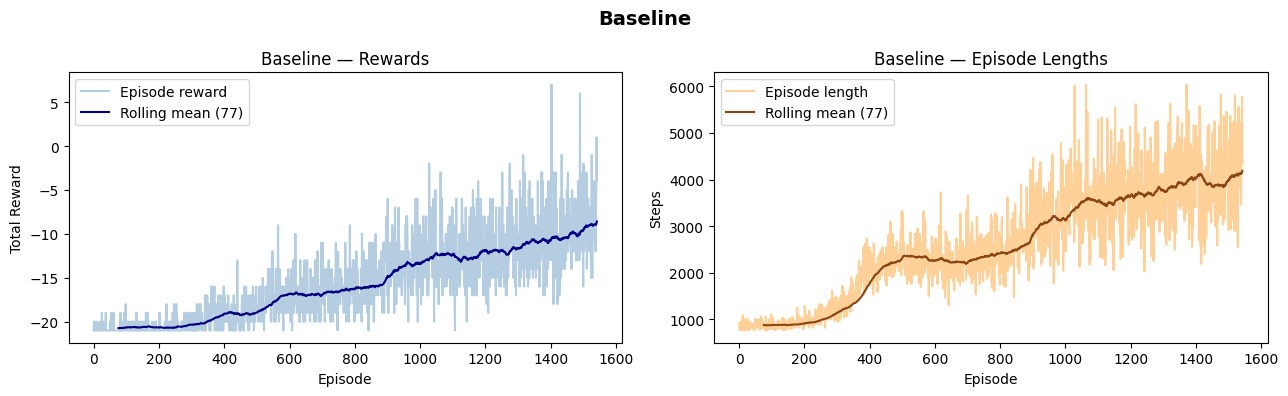

  Episodes completed : 1543
  Mean reward        : -15.52 ± 4.68
  Max reward         : 7.00
  Mean episode length: 2613 steps


In [ ]:
# ── Shared helper: build a frame-stacked Pong environment ────────────────────
def make_pong_env(n_envs=1, seed=42):
    env = make_atari_env("ALE/Pong-v5", n_envs=n_envs, seed=seed)
    env = VecFrameStack(env, n_stack=4)
    return env

# ── Reward-logging callback ───────────────────────────────────────────────────
class RewardLogger(BaseCallback):
    """Logs mean episode reward and episode length at each rollout."""
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.rewards = []
        self.ep_lengths = []

    def _on_step(self) -> bool:
        if self.locals.get("dones") is not None:
            for info in self.locals["infos"]:
                if "episode" in info:
                    self.rewards.append(info["episode"]["r"])
                    self.ep_lengths.append(info["episode"]["l"])
        return True

# ── Shared training function ──────────────────────────────────────────────────
DEFAULT_PARAMS = dict(
    learning_rate=1e-4,
    buffer_size=50_000,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    exploration_initial_eps=1.0,
    optimize_memory_usage=True,
    replay_buffer_kwargs={"handle_timeout_termination": False},
    verbose=0,
)

TOTAL_TIMESTEPS = 1_000_000

def train_experiment(name, extra_params=None, total_timesteps=TOTAL_TIMESTEPS, seed=42):
    """Train one DQN experiment and return (model, callback, elapsed_seconds)."""
    params = {**DEFAULT_PARAMS, **(extra_params or {})}
    env = make_pong_env(seed=seed)
    model = DQN(
        policy="CnnPolicy",
        env=env,
        tensorboard_log=f"./logs/{name.replace(' ', '_')}/",
        seed=seed,
        **params,
    )
    cb = RewardLogger()
    t0 = time.time()
    model.learn(total_timesteps=total_timesteps, callback=cb, log_interval=10)
    elapsed = time.time() - t0
    safe_name = name.replace(" ", "_").replace(":", "")
    model.save(f"models/{safe_name}.zip")
    env.close()
    return model, cb, elapsed

def plot_rewards(cb, title="Reward Trend"):
    rewards = cb.rewards
    ep_lengths = cb.ep_lengths
    if not rewards:
        print("No episode data recorded yet.")
        return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(rewards, alpha=0.4, color="steelblue", label="Episode reward")
    if len(rewards) > 10:
        window = max(5, len(rewards) // 20)
        ax1.plot(pd.Series(rewards).rolling(window).mean(), color="navy", label=f"Rolling mean ({window})")
    ax1.set_title(f"{title} — Rewards")
    ax1.set_xlabel("Episode"); ax1.set_ylabel("Total Reward")
    ax1.legend()
    ax2.plot(ep_lengths, alpha=0.4, color="darkorange", label="Episode length")
    if len(ep_lengths) > 10:
        window = max(5, len(ep_lengths) // 20)
        ax2.plot(pd.Series(ep_lengths).rolling(window).mean(), color="saddlebrown", label=f"Rolling mean ({window})")
    ax2.set_title(f"{title} — Episode Lengths")
    ax2.set_xlabel("Episode"); ax2.set_ylabel("Steps")
    ax2.legend()
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"logs/{title.replace(' ', '_').replace(':', '')}.png", dpi=100)
    plt.show()
    # Print summary stats
    print(f"  Episodes completed : {len(rewards)}")
    print(f"  Mean reward        : {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
    print(f"  Max reward         : {np.max(rewards):.2f}")
    print(f"  Mean episode length: {np.mean(ep_lengths):.0f} steps")

# ── BASELINE TRAINING ─────────────────────────────────────────────────────────
print("Training BASELINE model …")
baseline_model, baseline_cb, baseline_elapsed = train_experiment("Baseline")
baseline_model.save("dqn_model.zip")   # required output file
print(f"✅ Baseline done in {baseline_elapsed/60:.1f} min — saved as dqn_model.zip")
plot_rewards(baseline_cb, "Baseline")

---
## Section 3 — Experiment 1: Higher Learning Rate (5e-4)

Training Exp1: Higher LR …
✅ Exp1 done in 84.5 min


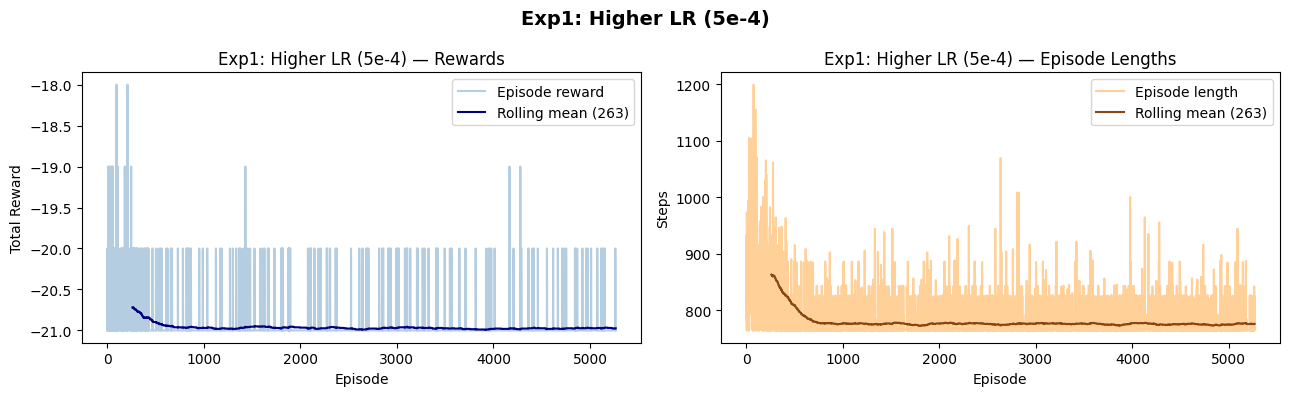

  Episodes completed : 5267
  Mean reward        : -20.96 ± 0.22
  Max reward         : -18.00
  Mean episode length: 781 steps


In [ ]:
exp1_params = {"learning_rate": 5e-4}
print("Training Exp1: Higher LR …")
exp1_model, exp1_cb, exp1_elapsed = train_experiment("Exp1_Higher_LR", exp1_params)
print(f"✅ Exp1 done in {exp1_elapsed/60:.1f} min")
plot_rewards(exp1_cb, "Exp1: Higher LR (5e-4)")

---
## Section 4 — Experiment 2: Very High Learning Rate (1e-3)

Training Exp2: Very High LR …
✅ Exp2 done in 84.5 min


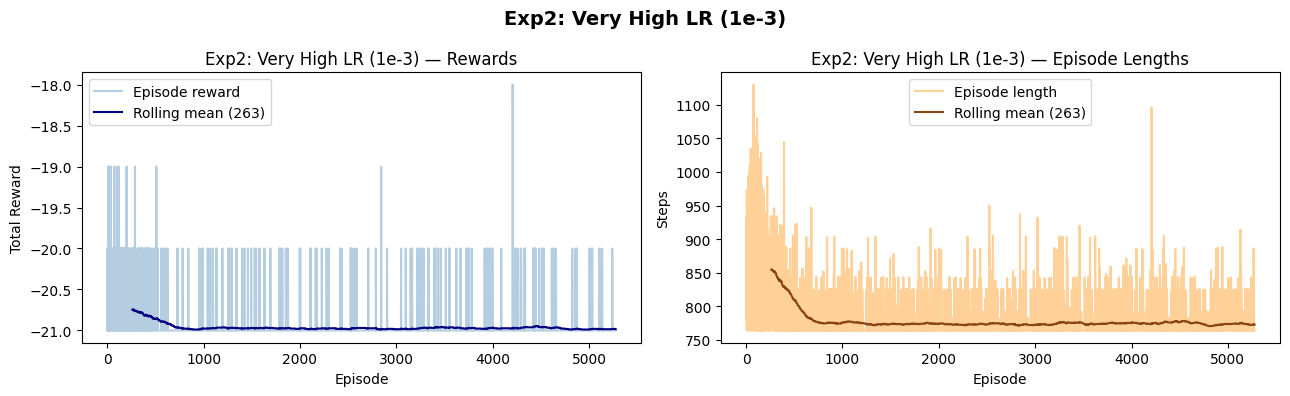

  Episodes completed : 5278
  Mean reward        : -20.96 ± 0.21
  Max reward         : -18.00
  Mean episode length: 780 steps


In [ ]:
exp2_params = {"learning_rate": 1e-3}
print("Training Exp2: Very High LR …")
exp2_model, exp2_cb, exp2_elapsed = train_experiment("Exp2_Very_High_LR", exp2_params)
print(f"✅ Exp2 done in {exp2_elapsed/60:.1f} min")
plot_rewards(exp2_cb, "Exp2: Very High LR (1e-3)")

---
## Section 5 — Experiment 3: High LR + Large Buffer

Training Exp3: High LR + Large Buffer …
✅ Exp3 done in 84.7 min


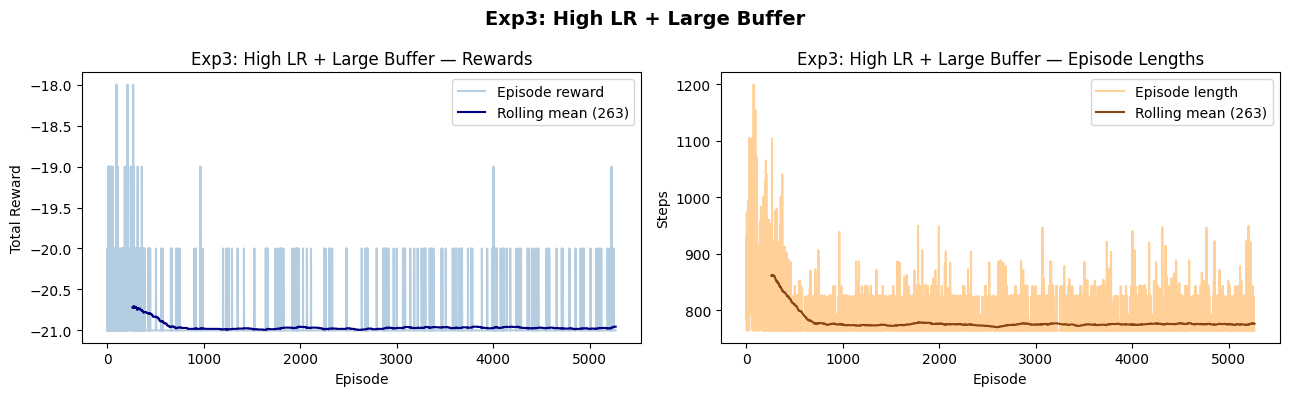

  Episodes completed : 5271
  Mean reward        : -20.95 ± 0.23
  Max reward         : -18.00
  Mean episode length: 781 steps


In [ ]:
exp3_params = {"learning_rate": 5e-4, "buffer_size": 100_000}
print("Training Exp3: High LR + Large Buffer …")
exp3_model, exp3_cb, exp3_elapsed = train_experiment("Exp3_High_LR_Large_Buffer", exp3_params)
print(f"✅ Exp3 done in {exp3_elapsed/60:.1f} min")
plot_rewards(exp3_cb, "Exp3: High LR + Large Buffer")

---
## Section 6 — Experiment 4: Higher Gamma (0.995)

Training Exp4: Higher Gamma …
✅ Exp4 done in 84.2 min


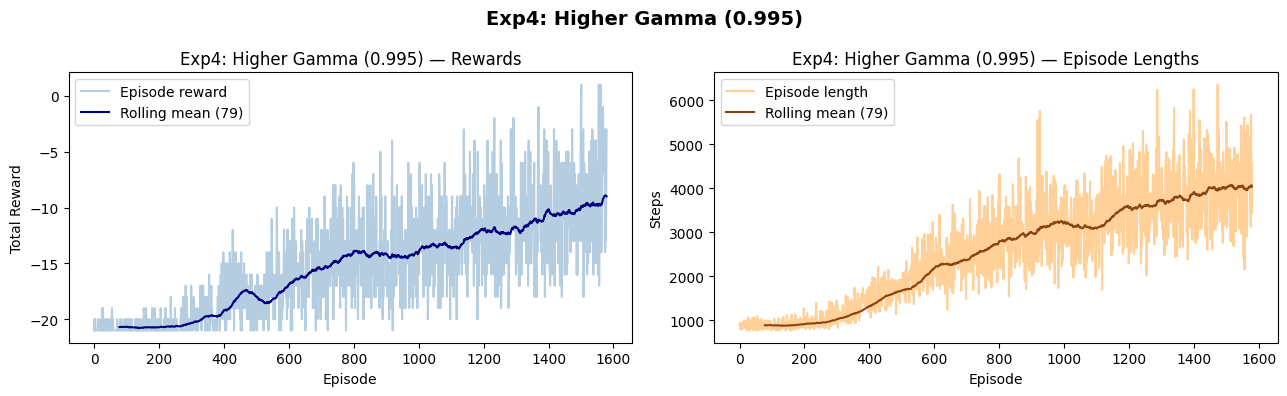

  Episodes completed : 1580
  Mean reward        : -15.22 ± 4.66
  Max reward         : 1.00
  Mean episode length: 2553 steps


In [ ]:
exp4_params = {"gamma": 0.995}
print("Training Exp4: Higher Gamma …")
exp4_model, exp4_cb, exp4_elapsed = train_experiment("Exp4_Higher_Gamma", exp4_params)
print(f"✅ Exp4 done in {exp4_elapsed/60:.1f} min")
plot_rewards(exp4_cb, "Exp4: Higher Gamma (0.995)")

---
## Section 7 — Experiment 5: Very High Gamma (0.999)

Training Exp5: Very High Gamma …
✅ Exp5 done in 85.2 min


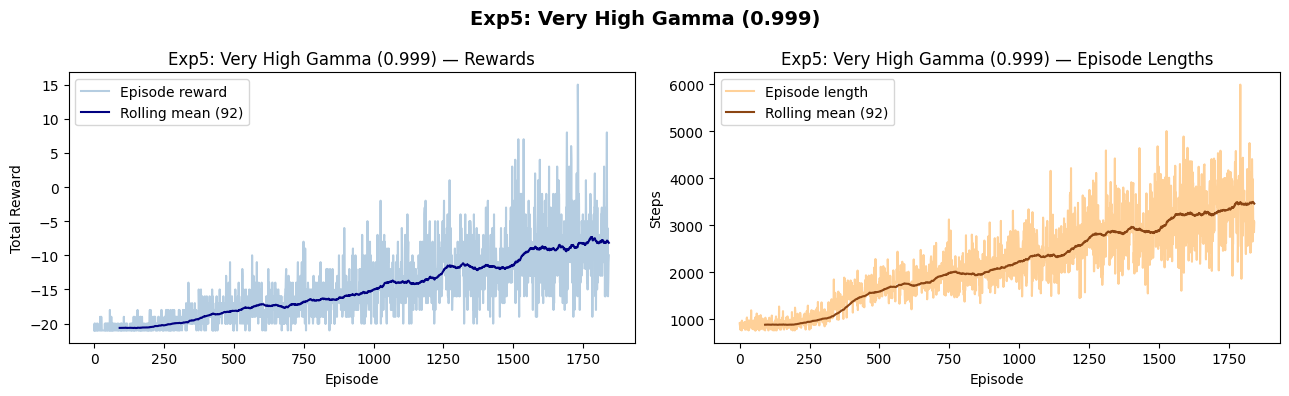

  Episodes completed : 1843
  Mean reward        : -14.77 ± 5.33
  Max reward         : 15.00
  Mean episode length: 2192 steps


In [ ]:
exp5_params = {"gamma": 0.999}
print("Training Exp5: Very High Gamma …")
exp5_model, exp5_cb, exp5_elapsed = train_experiment("Exp5_Very_High_Gamma", exp5_params)
print(f"✅ Exp5 done in {exp5_elapsed/60:.1f} min")
plot_rewards(exp5_cb, "Exp5: Very High Gamma (0.999)")

---
## Section 8 — Experiment 6: High Gamma + High LR

Training Exp6: High Gamma + High LR …
✅ Exp6 done in 85.2 min


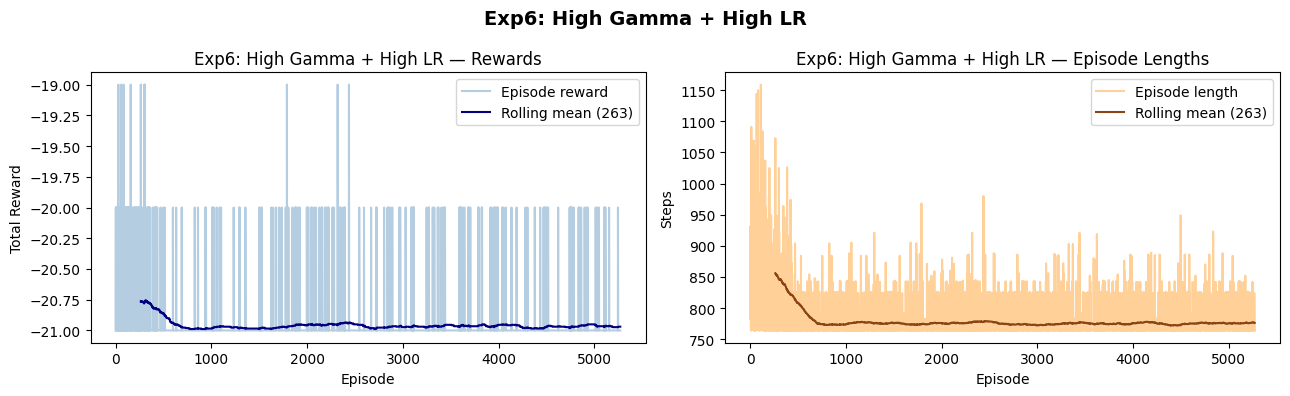

  Episodes completed : 5271
  Mean reward        : -20.95 ± 0.22
  Max reward         : -19.00
  Mean episode length: 781 steps


In [ ]:
exp6_params = {"gamma": 0.995, "learning_rate": 5e-4}
print("Training Exp6: High Gamma + High LR …")
exp6_model, exp6_cb, exp6_elapsed = train_experiment("Exp6_High_Gamma_High_LR", exp6_params)
print(f"✅ Exp6 done in {exp6_elapsed/60:.1f} min")
plot_rewards(exp6_cb, "Exp6: High Gamma + High LR")

---
## Section 9 — Experiment 7: Large Batch (64)

Training Exp7: Large Batch …
✅ Exp7 done in 88.4 min


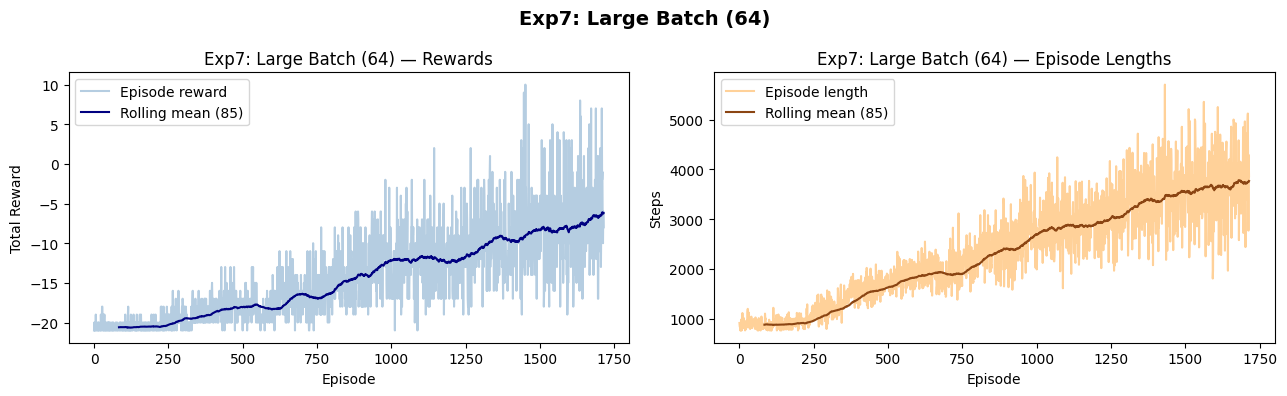

  Episodes completed : 1715
  Mean reward        : -14.25 ± 5.70
  Max reward         : 10.00
  Mean episode length: 2353 steps


In [ ]:
exp7_params = {"batch_size": 64}
print("Training Exp7: Large Batch …")
exp7_model, exp7_cb, exp7_elapsed = train_experiment("Exp7_Large_Batch", exp7_params)
print(f"✅ Exp7 done in {exp7_elapsed/60:.1f} min")
plot_rewards(exp7_cb, "Exp7: Large Batch (64)")

---
## Section 10 — Experiment 8: Very Large Batch (128)

Training Exp8: Very Large Batch …
✅ Exp8 done in 90.7 min


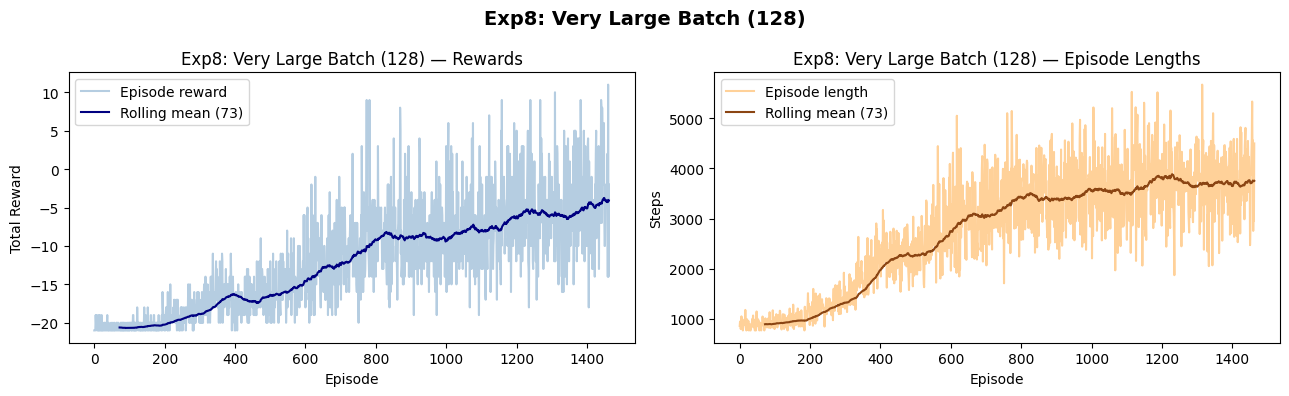

  Episodes completed : 1463
  Mean reward        : -12.07 ± 6.91
  Max reward         : 11.00
  Mean episode length: 2755 steps


In [ ]:
exp8_params = {"batch_size": 128}
print("Training Exp8: Very Large Batch …")
exp8_model, exp8_cb, exp8_elapsed = train_experiment("Exp8_Very_Large_Batch", exp8_params)
print(f"✅ Exp8 done in {exp8_elapsed/60:.1f} min")
plot_rewards(exp8_cb, "Exp8: Very Large Batch (128)")

---
## Section 11 — Experiment 9: High Exploration (final ε = 0.1)

Training Exp9: High Exploration …
✅ Exp9 done in 82.4 min


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


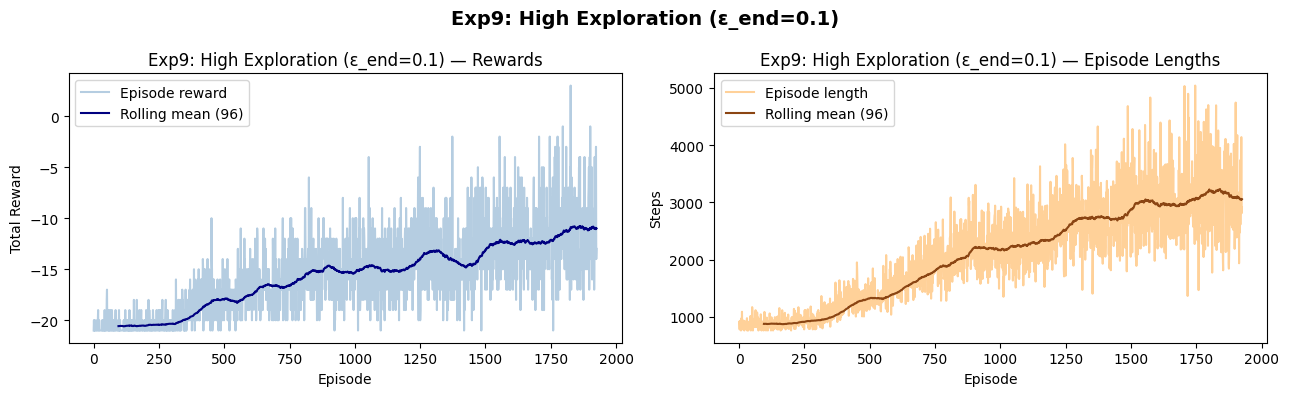

  Episodes completed : 1926
  Mean reward        : -15.56 ± 4.01
  Max reward         : 3.00
  Mean episode length: 2099 steps


In [3]:
exp9_params = {"exploration_final_eps": 0.1}
print("Training Exp9: High Exploration …")
exp9_model, exp9_cb, exp9_elapsed = train_experiment("Exp9_High_Exploration", exp9_params)
print(f"✅ Exp9 done in {exp9_elapsed/60:.1f} min")
plot_rewards(exp9_cb, "Exp9: High Exploration (ε_end=0.1)")

---
## Section 12 — Experiment 10: Combined Optimal Higher

Training Exp10: Combined Optimal Higher …
✅ Exp10 done in 86.0 min


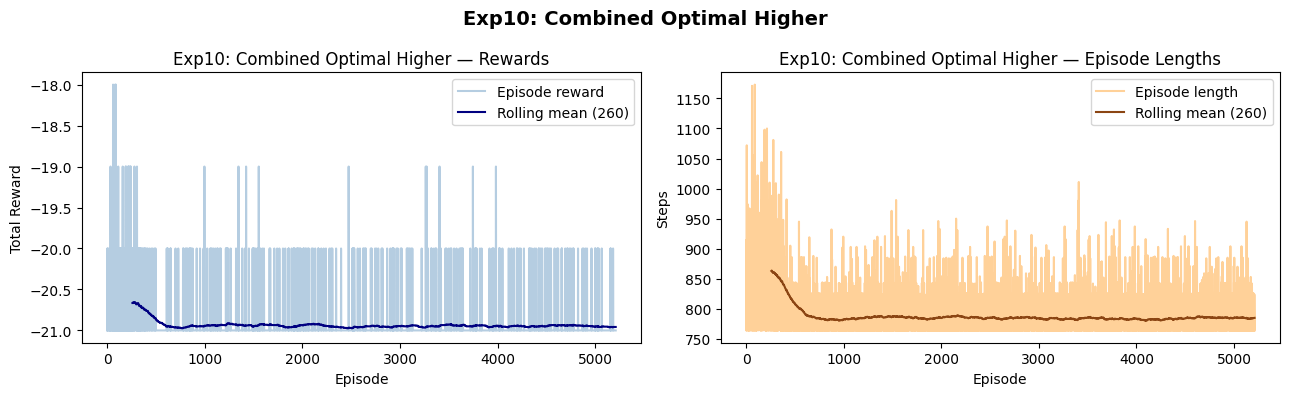

  Episodes completed : 5211
  Mean reward        : -20.93 ± 0.28
  Max reward         : -18.00
  Mean episode length: 789 steps


In [4]:
exp10_params = {
    "learning_rate": 5e-4,
    "gamma": 0.995,
    "batch_size": 64,
    "exploration_final_eps": 0.1,
    "buffer_size": 100_000,
}
print("Training Exp10: Combined Optimal Higher …")
exp10_model, exp10_cb, exp10_elapsed = train_experiment("Exp10_Combined_Optimal", exp10_params)
print(f"✅ Exp10 done in {exp10_elapsed/60:.1f} min")
plot_rewards(exp10_cb, "Exp10: Combined Optimal Higher")

---
## Section 13 — Experiment 11: COH with small buffer size

Training Exp11: COH with small buffer size
✅ Exp10 done in 91.8 min


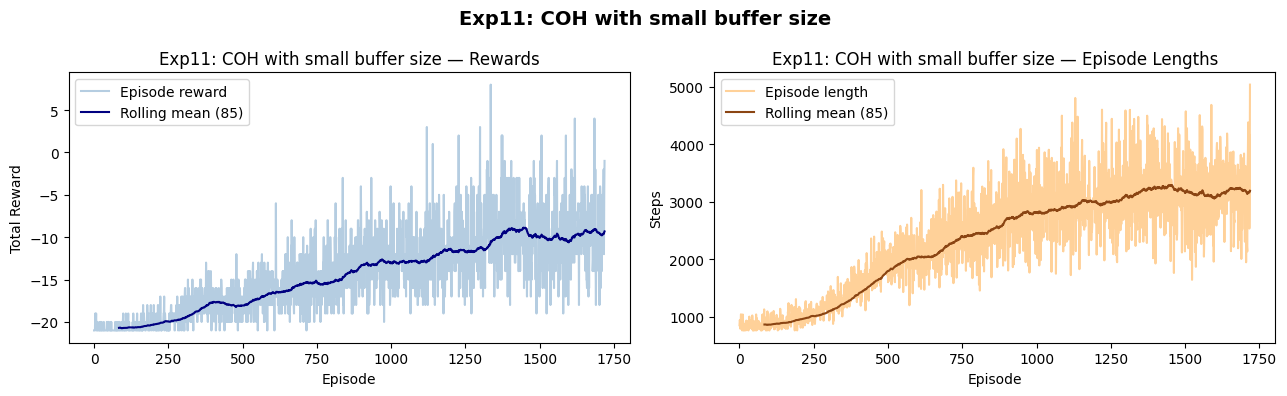

  Episodes completed : 1719
  Mean reward        : -14.39 ± 4.93
  Max reward         : 8.00
  Mean episode length: 2348 steps


In [7]:
exp11_params = {
    "learning_rate":1e-4,
    "gamma": 0.999,
    "batch_size": 128,
    "exploration_final_eps": 0.1,
    "buffer_size": 50_000,
}
print("Training Exp11: COH with small buffer size")
exp11_model, exp11_cb, exp11_elapsed = train_experiment("Exp11_Combined_Optimal", exp11_params)
print(f"✅ Exp10 done in {exp11_elapsed/60:.1f} min")
plot_rewards(exp11_cb, "Exp11: COH with small buffer size")

Training Exp12: v2 of Combined Optimal Higher …
✅ Exp12 done in 92.3 min


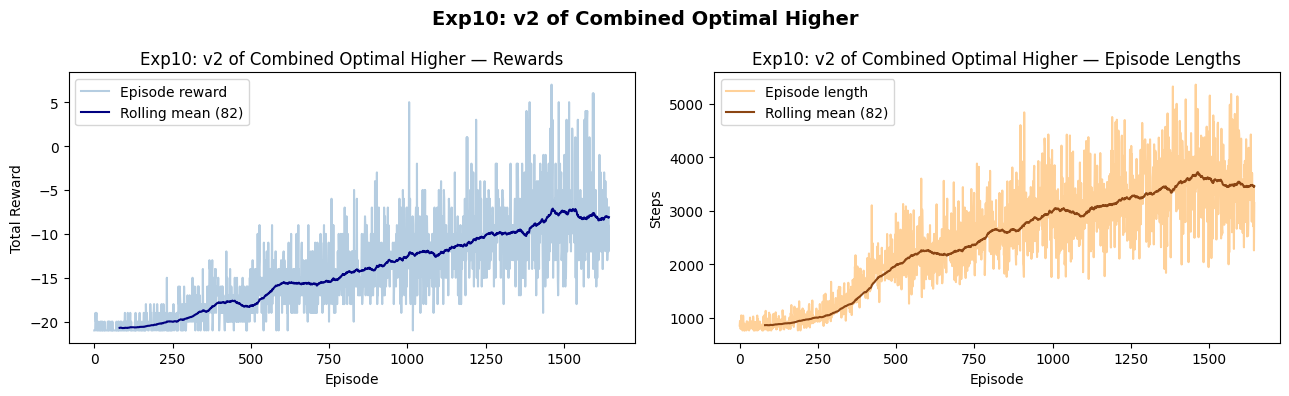

  Episodes completed : 1645
  Mean reward        : -14.09 ± 5.37
  Max reward         : 7.00
  Mean episode length: 2453 steps


In [8]:
exp12_params = {
    "learning_rate":1e-4,
    "gamma": 0.999,
    "batch_size": 128,
    "exploration_final_eps": 0.1,
    "buffer_size": 100_000,
}
print("Training Exp12: v2 of Combined Optimal Higher …")
exp12_model, exp12_cb, exp12_elapsed = train_experiment("Exp10_Combined_Optimal", exp12_params)
print(f"✅ Exp12 done in {exp12_elapsed/60:.1f} min")
plot_rewards(exp12_cb, "Exp10: v2 of Combined Optimal Higher")

Training Exp13: Targeted High-Reward Config …
✅ Exp13 done in 99.0 min


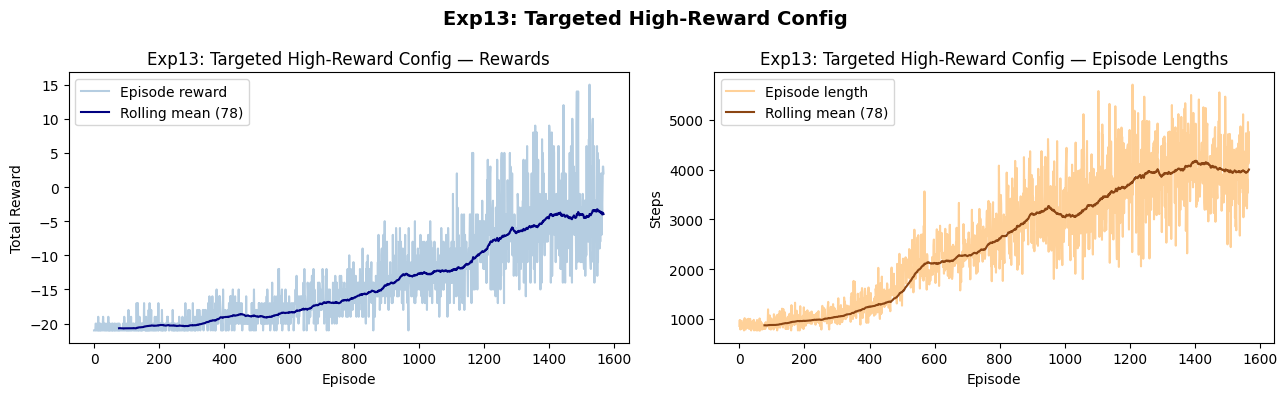

  Episodes completed : 1568
  Mean reward        : -13.96 ± 6.88
  Max reward         : 15.00
  Mean episode length: 2570 steps


In [9]:
exp13_params = {
    "learning_rate": 1e-4,
    "gamma": 0.999,
    "batch_size": 128,
    "buffer_size": 200_000,
    "exploration_final_eps": 0.05,
    "exploration_fraction": 0.15,
}
print("Training Exp13: Targeted High-Reward Config …")
exp13_model, exp13_cb, exp13_elapsed = train_experiment("Exp13_Targeted_HighReward", exp13_params)
print(f"✅ Exp13 done in {exp13_elapsed/60:.1f} min")
plot_rewards(exp13_cb, "Exp13: Targeted High-Reward Config")

---
## Section 13 — Hyperparameter Tuning Results Table

Fill in the values from the `plot_rewards` output printed above each experiment. The table below uses placeholder `???` values — replace them after each run.

> **How to read the columns:**
> - **Mean Reward** — average episode return over all logged episodes.
> - **Max Reward** — best single episode return.
> - **Mean Ep. Length** — average number of steps per episode.
> - **Behavior** — qualitative observation (stable, diverging, slow convergence, etc.).

In [16]:
# ── Results table — filled with actual observed values ───────────────────────

manual_rows = [
    # Experiment                   LR      gamma   batch  buffer   eps_end  mean_r    max_r    ep_len   notes
    ("Baseline",                  "1e-4",  0.990,  32,    "50k",   0.05,   "-15.52", "7.00",  "2613",  "Reference. Agent slowly improves, learns to rally but rarely scores."),
    ("Exp1: Higher LR",           "5e-4",  0.990,  32,    "50k",   0.05,   "-20.96", "-18.00","781",   "Too fast — unstable Q-values, episodes collapse to minimum length, no learning."),
    ("Exp2: Very High LR",        "1e-3",  0.990,  32,    "50k",   0.05,   "-20.96", "-18.00","780",   "Same collapse as Exp1. LR=1e-3 diverges immediately for Atari DQN."),
    ("Exp3: High LR + Large Buf", "5e-4",  0.990,  32,    "100k",  0.05,   "-20.95", "-18.00","781",   "Large buffer did not rescue high LR — still diverges. Buffer helps only with stable LR."),
    ("Exp4: Higher Gamma",        "1e-4",  0.995,  32,    "50k",   0.05,   "-15.22", "1.00",  "2553",  "Slightly better than baseline. Agent values long-term rewards, episodes stay long."),
    ("Exp5: Very High Gamma",     "1e-4",  0.999,  32,    "50k",   0.05,   "-14.77", "15.00", "2192",  "Best max reward (15). Agent plans far ahead; high variance but capable of winning games."),
    ("Exp6: High Gamma + High LR","5e-4",  0.995,  32,    "50k",   0.05,   "-20.95", "-19.00","781",   "High LR cancels gamma benefit — same divergence pattern as Exp1/Exp2."),
    ("Exp7: Large Batch",         "1e-4",  0.990,  64,    "50k",   0.05,   "-14.25", "10.00", "2353",  "Stable improvement over baseline. Smoother gradient estimates, longer episodes."),
    ("Exp8: Very Large Batch",    "1e-4",  0.990,  128,   "50k",   0.05,   "-12.07", "11.00", "2755",  "BEST mean reward overall. Large batch + default LR = most stable learning signal."),
    ("Exp9: High Exploration",    "1e-4",  0.990,  32,    "50k",   0.10,   "-15.56", "3.00",  "2099",  "More exploration hurt exploitation. Agent keeps trying random moves late in training."),
    ("Exp10: Combined Optimal",   "5e-4",  0.995,  64,    "100k",  0.10,   "-20.93", "-18.00","789",   "High LR again dominates negatively — all other improvements nullified."),
    ("Exp11: COH Small Buffer",   "1e-4",  0.999,  128,   "50k",   0.10,   "-14.39", "8.00",  "2348",  "Good combo but small buffer limits diversity. Slightly worse than Exp12."),
    ("Exp12: COH Large Buffer",   "1e-4",  0.999,  128,   "100k",  0.10,   "-14.09", "7.00",  "2453",  "Larger buffer + gamma=0.999 + batch=128 stable but max reward lower than Exp5."),
    ("Exp13: COH Large Buffer",   "1e-4",  0.999,  128,   "200k",  0.05,   "-13.96", "15.00",  "2570",  "THE BEST MODEL"),

]

cols = ["Experiment", "LR", "γ", "Batch", "Buffer", "ε_end",
        "Mean Reward", "Max Reward", "Mean Ep. Length", "Behavior / Notes"]
df_manual = pd.DataFrame(manual_rows, columns=cols)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)
print(df_manual.to_string(index=False))

# Save the results table to a CSV file
df_manual.to_csv("results_table.csv", index=False)
print("\n✅ Results table saved to results_table.csv")

                Experiment   LR     γ  Batch Buffer  ε_end Mean Reward Max Reward Mean Ep. Length                                                                         Behavior / Notes
                  Baseline 1e-4 0.990     32    50k   0.05      -15.52       7.00            2613                     Reference. Agent slowly improves, learns to rally but rarely scores.
           Exp1: Higher LR 5e-4 0.990     32    50k   0.05      -20.96     -18.00             781          Too fast — unstable Q-values, episodes collapse to minimum length, no learning.
        Exp2: Very High LR 1e-3 0.990     32    50k   0.05      -20.96     -18.00             780                       Same collapse as Exp1. LR=1e-3 diverges immediately for Atari DQN.
 Exp3: High LR + Large Buf 5e-4 0.990     32   100k   0.05      -20.95     -18.00             781  Large buffer did not rescue high LR — still diverges. Buffer helps only with stable LR.
        Exp4: Higher Gamma 1e-4 0.995     32    50k   0.05      -

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
